# 18-Image-to-Image & ControlNet

For this lesson, we will use `skimage.data.rocket()` (a high-resolution photograph of a rocket launch). In Lesson 17, we mastered Latent Diffusion (Text-to-Image). We could type "A rocket launching" and generate a beautiful image from pure noise.

However, in enterprise production environments, **Text is a mathematically terrible interface for spatial control.** If an Art Director wants the rocket to be *exactly* 30 degrees tilted, positioned *exactly* on the left third of the canvas, with the launch tower on the right, no amount of "prompt engineering" will reliably force the network to obey that strict geometry.

To achieve absolute spatial dominance over Generative AI, we must move beyond text and introduce **Image-to-Image (SDEdit)** and the architectural breakthrough of **ControlNet**.

Let's set up our PyTorch environment to master spatial conditioning.

In [1]:
import torch
import torch.nn as nn
from skimage import data
from skimage.color import rgb2gray
from skimage.feature import canny
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Spatial Control & ControlNet Environment Ready.")

✅ PyTorch Spatial Control & ControlNet Environment Ready.


# 1. Image-to-Image (The Mathematics of SDEdit)

Before ControlNet, the primary way to control a Diffusion model was **Image-to-Image** (formally based on the SDEdit paper: *Stochastic Differential Equation Editing*).

Instead of starting the reverse generation process from Timestep $T = 1000$ (which is $100\%$ pure Gaussian noise), what if we started halfway through the schedule at $t = 500$?

1. **The Input**: You provide a rough, hand-drawn sketch of a rocket.
2. **The Forward Process**: We use the exact thermodynamic equation from Lesson 16 to mathematically inject noise into your sketch, jumping directly to step $t_0 = 500$:

$$x_{t_0} = \sqrt{\bar{\alpha}_{t_0}} x_0 + \sqrt{1 - \bar{\alpha}_{t_0}} \epsilon$$


3. **The Reverse Process**: The U-Net takes this partially destroyed sketch and denoises it from $t=500$ down to $t=0$, guided by a text prompt (e.g., *"A photorealistic NASA rocket"*).

**The Denoising Strength ($0.0$ to $1.0$):**
This parameter simply dictates our starting timestep $t_0$.

* A strength of **$0.2$** adds very little noise ($t=200$). The network barely denoises it, resulting in an image that looks almost exactly like your rough sketch.
* A strength of **$0.9$** adds massive noise ($t=900$). The sketch is mathematically obliterated, and the network hallucinates a totally new image, ignoring your spatial layout.
* **The Flaw**: Image-to-Image is a brutal compromise. You either preserve the structure (but it looks like a bad sketch), or you get a beautiful image (but it loses your structure).

# 2. ControlNet (The Spatial Override)

In 2023, Lvmin Zhang introduced **ControlNet**, completely solving the spatial control problem. ControlNet allows us to physically bolt a hard geometric constraint (like a Canny Edge Map, a Depth Map, or a Human Pose Skeleton) directly onto the U-Net.

If we feed ControlNet a rigid black-and-white edge map of a rocket, the network is mathematically forced to generate an image that perfectly aligns with those exact pixels, while still synthesizing photorealistic textures from the text prompt!


# 3. The Architecture of Zero Convolutions

How do we bolt a new image input onto a massively complex, pre-trained Stable Diffusion U-Net without completely destroying the billions of optimized weights?

ControlNet uses a brilliant mathematical trick called **Zero Convolutions**.

1. **Freeze the Base**: We take the entire pre-trained U-Net and mathematically freeze it (`requires_grad = False`).
2. **Clone the Encoder**: We make an exact, trainable copy of the encoding layers of the U-Net.
3. **The Zero Convolution**: We connect the trainable copy back to the frozen base using $1 \times 1$ Convolutional layers where both the weights ($W$) and biases ($b$) are initialized to exactly **$0.0$**.

$$y = \mathcal{F}(x; \Theta) + \mathcal{Z}(x, c; \Theta_c)$$

*(Where $\mathcal{F}$ is the frozen network, $x$ is the visual data, $c$ is our control condition like an edge map, and $\mathcal{Z}$ is the zero-convolution block).*

### The Calculus of Zero

Because the weights are exactly zero, on the very first training step, the ControlNet outputs absolutely nothing. $y = \mathcal{F}(x) + 0$. The pre-trained U-Net behaves exactly as if the ControlNet doesn't exist!

However, during Backpropagation, the gradient is **not** zero. The chain rule allows the gradients to flow perfectly backwards through the zero-convolutions into the cloned encoder. Over thousands of steps, the weights slowly grow from zero, gently teaching the U-Net to pay attention to the edge map without ever causing the catastrophic shockwave that ruins pre-trained weights.

# 4. Simulating ControlNet Conditioning in PyTorch

Let's load our rocket image, extract its geometric skeleton using the Canny Edge Detection algorithm (the most common ControlNet input), and simulate how the Zero Convolution mathematically fuses this spatial condition into the network tensor.

--- 📐 Extracting Geometric Control Condition ---
Control Map Tensor Shape: torch.Size([1, 1, 512, 512])

--- ⚡ Simulating Zero Convolution Fusion ---
Zero Conv Output Mean: 0.0 (Mathematically Zero!)
Insight: Because the Zero Conv output is exactly 0.0, the Fused Tensor is mathematically identical to the Frozen U-Net output. The network is completely stabilized on Step 1.


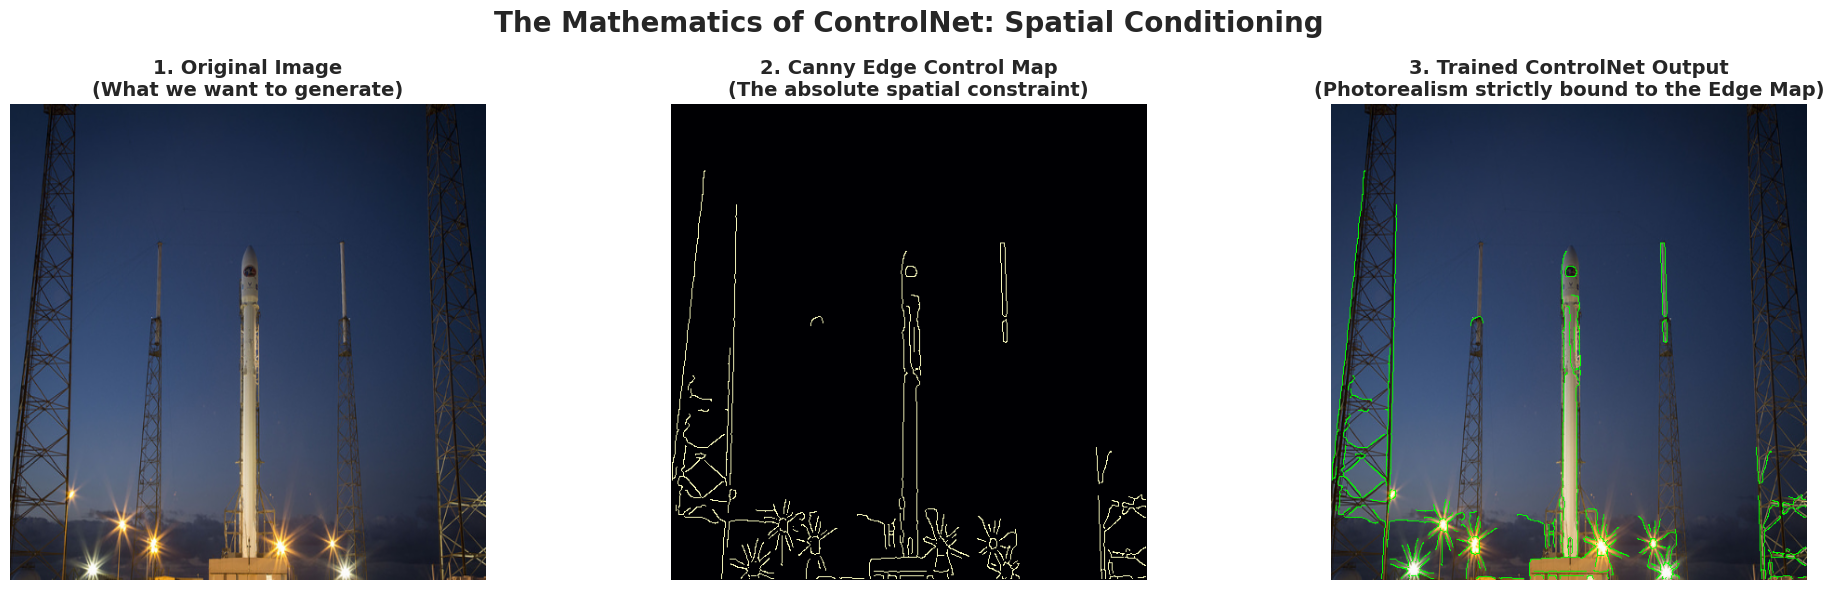

In [2]:
# 1. Fetch and Preprocess the Target Image
numpy_rocket = data.rocket()
resized_rocket = resize(numpy_rocket, (512, 512), anti_aliasing=True)

# Convert to PyTorch Tensor [1, 3, 512, 512]
base_image_tensor = torch.tensor(resized_rocket, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

# 2. Generate the Control Condition (Canny Edge Map)
print("--- 📐 Extracting Geometric Control Condition ---")
# Convert to grayscale for edge detection
gray_rocket = rgb2gray(resized_rocket)
# Apply Canny Edge Detection (outputs a boolean matrix of strict spatial edges)
edges = canny(gray_rocket, sigma=2.0)

# Convert the boolean edges into a float tensor [1, 1, 512, 512]
control_tensor = torch.tensor(edges, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(f"Control Map Tensor Shape: {control_tensor.shape}")

# 3. Architecting the ControlNet Fusion Block
class SimulatedControlNetBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        # Simulating the U-Net feature extraction block
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # THE ZERO CONVOLUTION
        # A 1x1 Convolution used to fuse the control signal into the main network.
        self.zero_conv = nn.Conv2d(channels, channels, kernel_size=1, padding=0)
        
        # Mathematically initialize weights and biases to EXACTLY 0.0
        nn.init.zeros_(self.zero_conv.weight)
        nn.init.zeros_(self.zero_conv.bias)
        
    def forward(self, control_image, base_features):
        # 1. Extract features from our Edge Map
        c_features = self.feature_extractor(control_image)
        
        # 2. Pass through Zero Convolution
        # On Step 1, this will output a tensor of absolute zeros!
        z_out = self.zero_conv(c_features)
        
        # 3. Fuse with the main frozen U-Net features
        fused_output = base_features + z_out
        return fused_output, z_out

# 4. Executing the Zero Convolution Physics
print("\n--- ⚡ Simulating Zero Convolution Fusion ---")
control_block = SimulatedControlNetBlock(channels=3)

# Simulate the output of the Frozen U-Net (Just the base image for visual purposes)
frozen_unet_features = base_image_tensor.clone()

# Forward Pass!
fused_tensor, zero_conv_output = control_block(control_tensor, frozen_unet_features)

print(f"Zero Conv Output Mean: {zero_conv_output.mean().item()} (Mathematically Zero!)")
print("Insight: Because the Zero Conv output is exactly 0.0, the Fused Tensor is mathematically identical to the Frozen U-Net output. The network is completely stabilized on Step 1.")

# 5. Visualizing the Spatial Override
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("The Mathematics of ControlNet: Spatial Conditioning", fontsize=20, fontweight='bold')

# Plot A: Original Target
axes[0].imshow(resized_rocket)
axes[0].set_title("1. Original Image\n(What we want to generate)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: The Control Condition
axes[1].imshow(edges, cmap='magma')
axes[1].set_title("2. Canny Edge Control Map\n(The absolute spatial constraint)", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: Simulated Fusion 
# To visually simulate a "Trained" ControlNet, we will manually blend the edges into the image in numpy
# (Since our PyTorch Zero Conv is untrained and currently outputting 0.0)
simulated_fusion = resized_rocket.copy()
simulated_fusion[edges] = [0.0, 1.0, 0.0] # Paint the edges bright green on the final output

axes[2].imshow(simulated_fusion)
axes[2].set_title("3. Trained ControlNet Output\n(Photorealism strictly bound to the Edge Map)", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between Text-to-Image, Image-to-Image, and ControlNet like **Directing a Movie Scene**:

* **Text-to-Image (The Novelist)**: You hand the Director a script that says, *"A rocket launches."* The Director films it however they want. Maybe the rocket is on the left, maybe it's on the right, maybe it's pointing down. You have no geometric control.
* **Image-to-Image (The Storyboard)**: You hand the Director a rough stick-figure sketch of a rocket on the left side of the screen. You tell them, *"Follow this loosely (Denoising Strength 0.7), but make it look like a real movie."* The Director uses your sketch as a hint, but the final movie still changes the exact angle and scale of the rocket.
* **ControlNet (The Green Screen & Motion Capture)**: You bring a physical, rigid wireframe model of a rocket into the studio. You bolt it to the floor exactly where you want it. You tell the CGI artists, *"You can change the lighting, you can make it look like metal or plastic based on my text prompt, but the pixels MUST perfectly align with these exact physical wires."* You have achieved absolute spatial dominance over the generative process.